# HOW TO USE SimNIBS -> PlanTUS
# https://simnibs.github.io/simnibs/build/html/index.html
# https://simnibs.github.io/simnibs/build/html/documentation/command_line/charm.html

# Steps
# - run segmentation with SimNIBS
# - run PlanTUS with appropriate settings of TUS and get coordinates
# - use a code chunk (# Step4: Output optimized TUS transducer positions) to produce a txt to load to BS

In [ ]:
# ---------------
# Step1-1: Creates a tetrahedral head mesh from T1- and T2-weighted structural MR images 
# ---------------

#  OPTIONAL (in terminal): using FSL fslorient, copy sform -> qform
fslorient -copysform2qform T1.nii.gz

# Run charm (without [])
charm [subid] [path]/[name of file]_T1.nii.gz


In [1]:
# ---------------
# Define basic information and load packages
# ---------------
%reset -f

# Load modules/packages
from basic_python import * # now added to startup folder
from mri_python import * 
globals().update(configure_mri_env())

# Nipype
import nibabel as nib
from nipype.interfaces.spm import NewSegment
from nipype.interfaces.matlab import MatlabCommand
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation
os.environ["NILEARN_DATA"] = "/Users/atsushikikumoto/Dropbox/w_ONGOINGANY/atlases"

# Nilearn
from nilearn import datasets, image, masking, plotting
from nilearn.image import math_img, resample_to_img, new_img_like

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define paths 
DIR_BASE = Path.home()  / "Dropbox"
DIR_DATA = DIR_BASE / "w_SCRIPTS" / "P.TUSPractice" / "SUB_LIST_PREP" 
# DIR_DATA = DIR_BASE / "w_SCRIPTS" / "P.TUSPractice" / "TUS_LSRDM" / "PilotData" / "LCScan_Pilot"/ "7T"

DIR_TISSUES = list(DIR_DATA.rglob('final_tissues.nii.gz'))


/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_13625/35628072.py:43: FutureWarning:

'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.

/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_13625/35628072.py:43: FutureWarning:

From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.



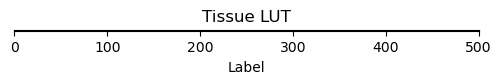

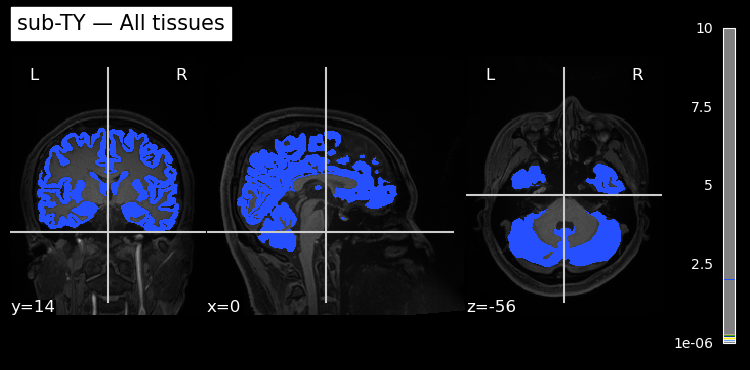

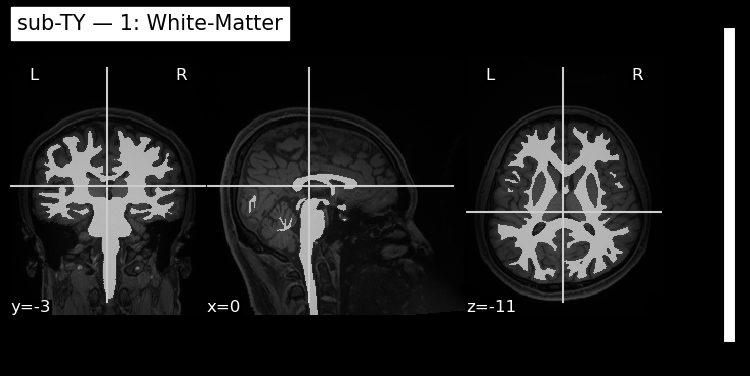

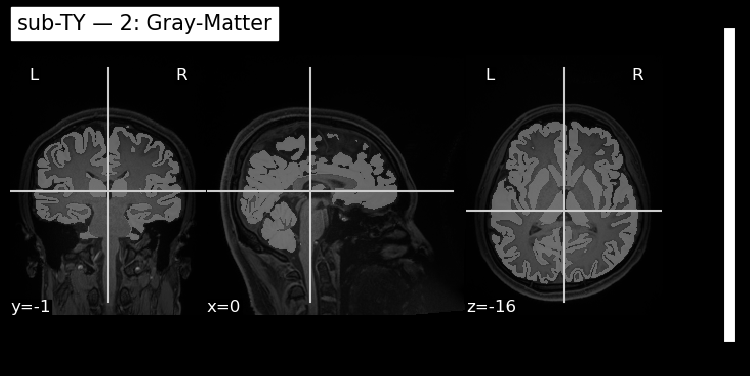

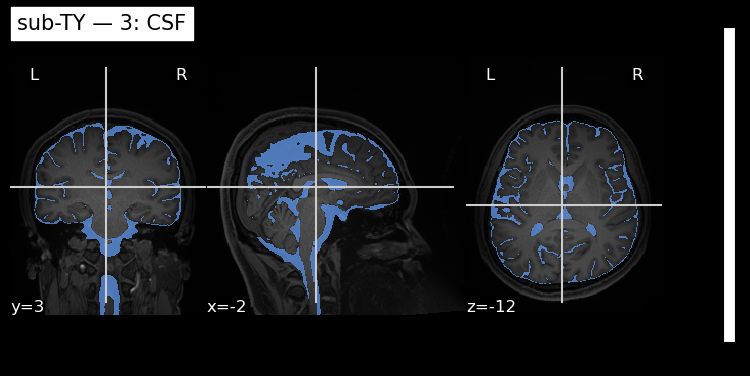

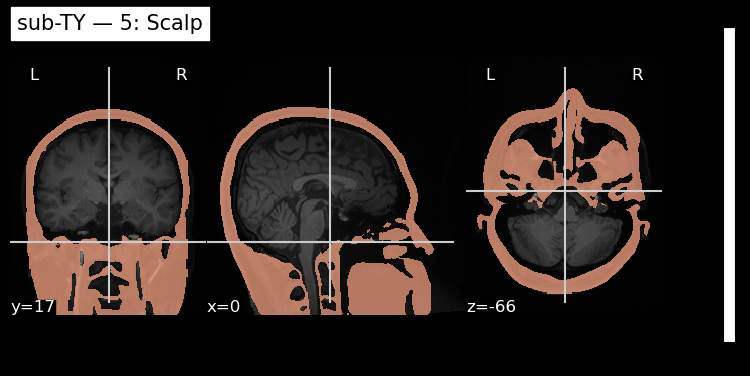

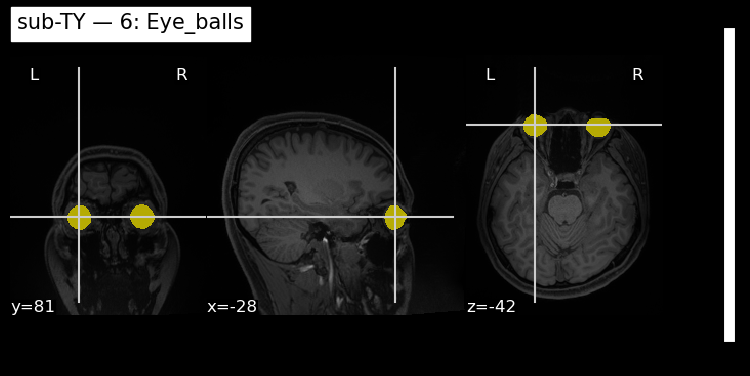

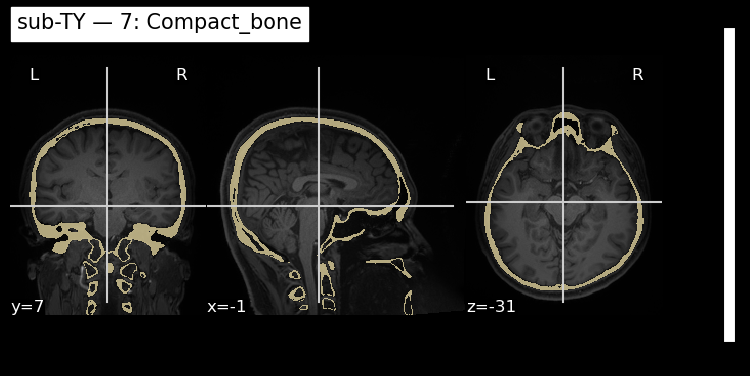

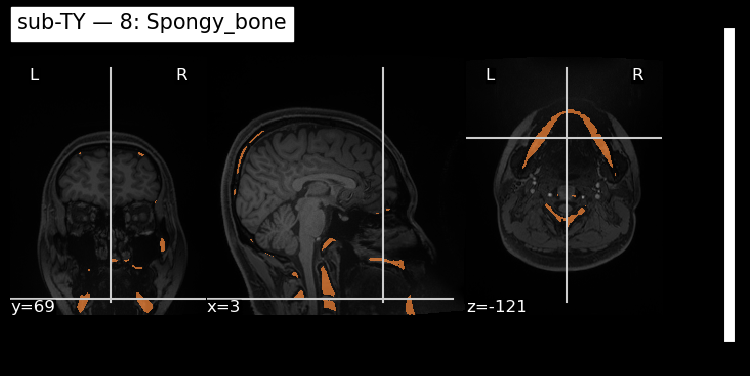

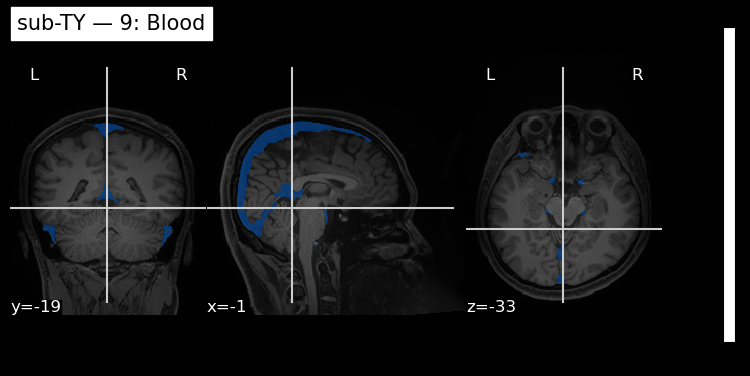

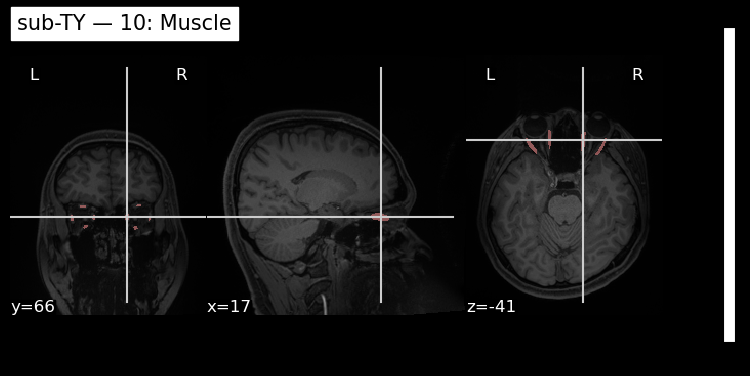

In [ ]:
# ---------------
# Step1-2: Check segmentations
# ---------------


# =============================
# 1. Select subject + load data
# =============================
sub_id = "sub-NS"

# find its m2m folder
dirnames = [p.parent.name for p in DIR_TISSUES]
sub_idx = dirnames.index(f"m2m_{sub_id}")

tissue_path = DIR_TISSUES[sub_idx]
m2m_dir = tissue_path.parent

tissues_img = nib.load(str(tissue_path))
tissues = tissues_img.get_fdata().astype(int)
labels_present = np.unique(tissues)

# =============================
# 2. Load LUT
# =============================
lut_path = m2m_dir / "final_tissues_LUT.txt"
lut = {}

with open(lut_path) as f:
    for line in f:
        parts = line.split()
        if len(parts) < 6 or not parts[0].isdigit():
            continue
        idx = int(parts[0])
        name = parts[1]
        R, G, B, A = map(int, parts[-4:])
        lut[idx] = {"name": name, "color": tuple(c/255 for c in (R, G, B, A))}

# =============================
# 3. Load subject T1 (background)
# =============================
# SimNIBS always produces T1fs_conform
bg_img_native = nib.load(str(m2m_dir / "T1.nii.gz"))
bg_img = image.resample_to_img(bg_img_native, tissues_img)

# =============================
# 4. Build LUT colormap
# =============================
max_label = max(lut.keys()) + 1
colors = np.zeros((max_label, 4))
for k, info in lut.items():
    colors[k] = info["color"]
cmap = ListedColormap(colors)

# =============================
# 5. Overview plot
# =============================
plt.figure(figsize=(6,1))
plt.imshow([np.arange(max_label)], cmap=cmap)
plt.yticks([]); plt.xlabel("Label"); plt.title("Tissue LUT"); plt.show()

plotting.plot_stat_map(
    image.new_img_like(tissues_img, tissues.astype(np.int16)),
    bg_img=bg_img,
    cmap=cmap,
    interpolation="nearest",
    title=f"{sub_id} — All tissues"
)
plotting.show()

# =============================
# 6. Plot each tissue
# =============================
for lab in labels_present:
    if lab == 0 or lab not in lut:
        continue

    mask = (tissues == lab).astype(np.uint8)
    if not np.any(mask):
        continue

    name = lut[lab]["name"]
    color = lut[lab]["color"]

    plotting.plot_roi(
        nib.Nifti1Image(mask, tissues_img.affine),
        bg_img=bg_img,
        cmap=ListedColormap([color]),
        display_mode="ortho",
        title=f"{sub_id} — {lab}: {name}"
    )

plotting.show()


In [ ]:
# ---------------
# Step2: Use PlanTUS
# ---------------

# 1. download SimNIBS, freesurfer, fsl 
# -
# 2. download nilearn and other dependencies into python env of SimNINBS
# - vtk, nilearn, 
# 3. Fix PlanTUS
# - replace "dtype=np.float" as "dtype=float"
    
# need to use SimNIBS python
/Users/atsushikikumoto/Applications/SimNIBS-4.5/simnibs_env/bin/python \
    /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/RESOURCE/PlanTUS/PlanTUS_wrapper_CTX500.py

/Users/atsushikikumoto/Applications/SimNIBS-4.5/simnibs_env/bin/python \
    /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/RESOURCE/PlanTUS/PlanTUS_wrapper_DPX500.py



In [ ]:
# ---------------
# Step3: Output optimized TUS transducer positions (PlanTUS focus-based)
# ---------------
import numpy as np
from pathlib import Path
import nibabel as nib


def write_brainsight_txt(transducer_mat_path, entry_las, target_las, out_path, name="TUS_Target"):
    """
    transducer_mat_path : 4x4 transducer matrix in RAS (PlanTUS / SimNIBS)
                          → rotation only is used
    entry_las           : entry coordinate in LAS/Scanner space (mm)
    target_las          : target (focus) coordinate in LAS/Scanner space (mm)
    out_path            : Brainsight-compatible txt
    """

    # ============================
    # Load transducer matrix
    # ============================
    M = np.loadtxt(transducer_mat_path)
    if M.shape != (4, 4):
        raise ValueError(f"Expected 4x4 matrix, got {M.shape}")

    # Rotation only（そのまま使う）
    R_las = M[:3, :3].copy()
    R_las[:, 2] /= np.linalg.norm(R_las[:, 2])   # normalize beam direction

    entry_las  = np.asarray(entry_las, float)
    target_las = np.asarray(target_las, float)

    # ============================
    # Header
    # ============================
    header = (
        "# Version: 13\n"
        "# Coordinate system: NIfTI:Scanner\n"
        "# Created by: PlanTUS_to_Brainsight (fixed)\n"
        "# Units: millimetres, degrees, milliseconds, and microvolts\n"
        "# Encoding: UTF-8\n"
        "# Notes: Each column is delimited by a tab. Each value within a column is delimited by a semicolon.\n"
        "# Target Name\tLoc. X\tLoc. Y\tLoc. Z\t"
        "m0n0\tm0n1\tm0n2\tm1n0\tm1n1\tm1n2\tm2n0\tm2n1\tm2n2\n"
    )

    def fmt_row(label, loc):
        return (
            f"{label}\t"
            f"{loc[0]:.4f}\t{loc[1]:.4f}\t{loc[2]:.4f}\t"
            f"{R_las[0,0]:.4f}\t{R_las[0,1]:.4f}\t{R_las[0,2]:.4f}\t"
            f"{R_las[1,0]:.4f}\t{R_las[1,1]:.4f}\t{R_las[1,2]:.4f}\t"
            f"{R_las[2,0]:.4f}\t{R_las[2,1]:.4f}\t{R_las[2,2]:.4f}\n"
        )

    # ============================
    # Write file
    # ============================
    with open(out_path, "w") as f:
        f.write(header)
        f.write(fmt_row(f"{name}_target", target_las))
        f.write(fmt_row(f"{name}_entry",  entry_las))

    print("Saved BrainSight file:", out_path)
    print("  Target (Scanner):", target_las)
    print("  Entry  (Scanner):", entry_las)


# ============================================
# 1. Select subject
# ============================================
sub_id = "sub-02HI"   # ← 各自変更

dirnames = [p.parent.name for p in DIR_TISSUES]
sub_idx = dirnames.index(f"m2m_{sub_id}")

tissue_path = DIR_TISSUES[sub_idx]
m2m_dir = tissue_path.parent
print("m2m_dir:", m2m_dir)

# ============================================
# 2. Target selection
# ============================================
# aMCC_NeuroSynthTopic112
# Ce_CeA / BNT_BNST
# IFJ / FEF
# dIg_L_OR_dIg_R
target_name = "aMCC_NeuroSynthTopic112"
target_side = "_R"

plantus_root = m2m_dir / "PlanTUS"
target_folder = plantus_root / f"{sub_id}_T1w_{target_name}_mask_native{target_side}"
print("PlanTUS target folder:", target_folder)

# ============================================
# 3. Vertex directory
# ============================================
vtx_dirs = list(target_folder.glob("vtx*"))
if len(vtx_dirs) != 1:
    raise RuntimeError(f"Expected exactly one vtx directory, found {len(vtx_dirs)} in {target_folder}")

vtx_dir = vtx_dirs[0]
vtx_id = int(vtx_dir.name.replace("vtx", ""))
print("Using vtx directory:", vtx_dir, "(vtx ID:", vtx_id, ")")

# ============================================
# 4. ENTRY from skin surface
# ============================================
scalp_path = target_folder / "skin.surf.gii"
gii = nib.load(str(scalp_path))
coords = gii.darrays[0].data

entry_ras = coords[vtx_id]
entry_las = entry_ras.copy()        # ★ ここでもう X 反転しない

print("Entry RAS/Scanner:", entry_ras)
print("Entry for BrainSight (Scanner):", entry_las)

# ============================================
# 5. FOCUS from focus_position_matrix
# ============================================
focus_matrix = next(vtx_dir.glob("focus_position_matrix_*.txt"))
print("Focus matrix file:", focus_matrix)

M_focus = np.loadtxt(focus_matrix)
target_ras = M_focus[:3, 3]

target_las = target_ras.copy()      # ★ ここも X 反転しない

print("Focus RAS/Scanner:", target_ras)
print("Target for BrainSight (Scanner):", target_las)

# ============================================
# 6. Transducer rotation
# ============================================
trans_mat = next(vtx_dir.glob("*_transducer.txt"))
print("Transducer matrix file:", trans_mat)

# ============================================
# 7. Output
# ============================================
out_txt = target_folder / f"{sub_id}_T1w_{target_name}{target_side}_target_coordinates_Brainsight_PlanTUS.txt"
print("Output file:", out_txt)

write_brainsight_txt(
    transducer_mat_path=trans_mat,
    entry_las=entry_las,
    target_las=target_las,
    out_path=out_txt,
    name=f"{sub_id}_T1w_{target_name}{target_side}"
)


m2m_dir: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_PREP/02HO/m2m_sub-02HO
PlanTUS target folder: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_PREP/02HO/m2m_sub-02HO/PlanTUS/sub-02HO_T1w_aMCC_NeuroSynthTopic112_mask_native_R
Using vtx directory: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_PREP/02HO/m2m_sub-02HO/PlanTUS/sub-02HO_T1w_aMCC_NeuroSynthTopic112_mask_native_R/vtx4729 (vtx ID: 4729 )
Entry RAS/Scanner: [-4.879955 50.80643  61.10366 ]
Entry for BrainSight (Scanner): [-4.879955 50.80643  61.10366 ]
Focus matrix file: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/SUB_LIST_PREP/02HO/m2m_sub-02HO/PlanTUS/sub-02HO_T1w_aMCC_NeuroSynthTopic112_mask_native_R/vtx4729/focus_position_matrix_sub-02HO_T1w_aMCC_NeuroSynthTopic112_mask_native_R_vtx4729.txt
Focus RAS/Scanner: [-1.88238297 25.40190397 28.5523998 ]
Target for BrainSight (Scanner): [-1.88238297 25.40190397 28.5523998 ]
Transducer matrix file: /Users/atsushikikum

# PlanTUS Outputs → BrainSight (Quick Guide)

## What BrainSight Actually Needs
BrainSight does **not** use PlanTUS `.stl`, `.surf.gii`, or `.func.gii` files.

It only needs:
1. **T1w native MRI**
2. **Target + Entry point coordinates (LAS) in a TXT file**

---

## What PlanTUS Outputs Are For
These files are **for planning only**, not for BrainSight import:

### 3D surfaces
- `skin.stl`, `skull.stl`, `*_3Dmodel.stl`

### Surface/metric maps
- `angles_skin.func.gii`
- `skin_skull_angles_skin.func.gii`
- `distances_skin.func.gii`, `distances_skin_thresholded.func.gii`
- `avoidance_skin.func.gii`
- `target_intersection_skin.func.gii`

### Others
- `scene.scene`（Workbench用）
- `*_mask_native.nii.gz`（ターゲット位置確認用）

---

## Practical Workflow
1. Open **scene.scene** in Workbench  
2. Inspect:
   - angle maps  
   - avoidance mask  
   - distance map  
3. Choose the **skin entry point**  
4. Extract coordinates (RAS/LPS → LAS)  
5. Create BrainSight TXT:



In [ ]:
# ---------------
# Optional: adjust color range in .scene file
# ---------------


# from pathlib import Path

# # Base PlanTUS directory (DIR_BASE must be defined earlier in your script)
# DIR_PLANTUS = DIR_BASE / "w_SCRIPTS" / "P.TUSPractice" / "RESOURCE" / "PlanTUS"
# DIR_SCENETMP = DIR_PLANTUS / "resources" / "scene_templates"

# # Source (original) template
# src = DIR_SCENETMP / "TUSTransducerPlacementPlanning_TEMPLATE.scene"
# text_orig = src.read_text()


# def patch_user_scale(s: str, filename_placeholder: str, values):
#     """
#     Replace the UserScaleValues for the metric whose CaretDataFile Name
#     matches `filename_placeholder`.

#     This function is robust to two cases:
#       - <UserScaleValues> ... </UserScaleValues>
#       - &lt;UserScaleValues&gt; ... &lt;/UserScaleValues&gt;

#     It searches from the CaretDataFile tag onward in the full string,
#     rather than trying to isolate a sub-segment.
#     """
#     # Locate the CaretDataFile block for the given placeholder
#     tag = f'CaretDataFile" Name="{filename_placeholder}"'
#     start = s.index(tag)  # raises if the name does not exist

#     # Try both real XML and XML-escaped tags
#     open_candidates = ["<UserScaleValues>", "&lt;UserScaleValues&gt;"]
#     close_map = {
#         "<UserScaleValues>": "</UserScaleValues>",
#         "&lt;UserScaleValues&gt;": "&lt;/UserScaleValues&gt;",
#     }

#     us_open = None
#     open_tag = None
#     for cand in open_candidates:
#         try:
#             us_open = s.index(cand, start)
#             open_tag = cand
#             break
#         except ValueError:
#             continue

#     if us_open is None:
#         raise ValueError(
#             f"UserScaleValues not found after CaretDataFile Name=\"{filename_placeholder}\""
#         )

#     close_tag = close_map[open_tag]
#     us_start = us_open + len(open_tag)
#     us_end = s.index(close_tag, us_start)

#     # Existing values (for logging)
#     old_vals = s[us_start:us_end].strip()
#     new_vals = " ".join(f"{v:.6f}" for v in values)

#     print(f"[{filename_placeholder}] UserScaleValues:")
#     print("  OLD:", old_vals)
#     print("  NEW:", new_vals)

#     # Replace only the inner content between the open/close tags
#     return s[:us_start] + new_vals + s[us_end:]


# def make_device_template(
#     base_text: str,
#     out_filename: str,
#     distance_scale: tuple[float, float, float, float],
# ):
#     """
#     Create a device-specific planning template by patching the distance
#     color scale (DISTANCES_FILENAME + DISTANCES_MAX_FILENAME) and
#     writing a new .scene file.
#     """
#     patched = base_text
#     for name in ("DISTANCES_FILENAME", "DISTANCES_MAX_FILENAME"):
#         patched = patch_user_scale(patched, name, distance_scale)

#     dst = DIR_SCENETMP / out_filename
#     dst.write_text(patched)
#     print("Wrote device-specific template:", dst)
#     return patched


# # ==== CTX-500 (shallower focus) ==========================================
# # For CTX-500, we want the distance-related maps to use a fixed 0–70 mm scale.
# # The four values are interpreted approximately as:
# #   [min_value, low_threshold, high_threshold, max_value]
# # To guarantee that 0 is included as the lower bound, we set:
# #   min_value = 0, low_threshold = 0.
# distance_scale_ctx = (0.0, 0.0, 50.0, 70.0)

# patched_ctx = make_device_template(
#     base_text=text_orig,
#     out_filename="TUSTransducerPlacementPlanning_TEMPLATE_CTX500.scene",
#     distance_scale=distance_scale_ctx,
# )

# # ==== DPX-500 (deeper focus) ============================================
# # DPX-500 has a deeper focal range (~50–120 mm), so we use a wider 0–130 mm
# # scale for the distance metrics, again forcing the lower bound to include 0.
# distance_scale_dpx = (0.0, 0.0, 90.0, 130.0)

# patched_dpx = make_device_template(
#     base_text=text_orig,
#     out_filename="TUSTransducerPlacementPlanning_TEMPLATE_DPX500.scene",
#     distance_scale=distance_scale_dpx,
# )

# # Optional sanity check: print the patched UserScaleValues for DPX-500
# for name in ("DISTANCES_FILENAME", "DISTANCES_MAX_FILENAME"):
#     tag = f'CaretDataFile" Name="{name}"'
#     start = patched_dpx.index(tag)
#     open_candidates = ["<UserScaleValues>", "&lt;UserScaleValues&gt;"]
#     open_tag = None
#     for cand in open_candidates:
#         try:
#             us_open = patched_dpx.index(cand, start)
#             open_tag = cand
#             break
#         except ValueError:
#             continue
#     if open_tag is None:
#         print(f"[WARN] {name}: UserScaleValues not found in DPX template")
#         continue
#     close_tag = {
#         "<UserScaleValues>": "</UserScaleValues>",
#         "&lt;UserScaleValues&gt;": "&lt;/UserScaleValues&gt;",
#     }[open_tag]
#     us_start = us_open + len(open_tag)
#     us_end = patched_dpx.index(close_tag, us_start)
#     print("[DPX]", name, "=>", patched_dpx[us_start:us_end].strip())


[DISTANCES_FILENAME] UserScaleValues:
  OLD: -100.000000 0.000000 60.000000 100.000000
  NEW: 0.000000 0.000000 50.000000 70.000000
[DISTANCES_MAX_FILENAME] UserScaleValues:
  OLD: -100.000000 0.000000 0.000000 100.000000
  NEW: 0.000000 0.000000 50.000000 70.000000
Wrote device-specific template: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/RESOURCE/PlanTUS/resources/scene_templates/TUSTransducerPlacementPlanning_TEMPLATE_CTX500.scene
[DISTANCES_FILENAME] UserScaleValues:
  OLD: -100.000000 0.000000 60.000000 100.000000
  NEW: 0.000000 0.000000 90.000000 130.000000
[DISTANCES_MAX_FILENAME] UserScaleValues:
  OLD: -100.000000 0.000000 0.000000 100.000000
  NEW: 0.000000 0.000000 90.000000 130.000000
Wrote device-specific template: /Users/atsushikikumoto/Dropbox/w_SCRIPTS/P.TUSPractice/RESOURCE/PlanTUS/resources/scene_templates/TUSTransducerPlacementPlanning_TEMPLATE_DPX500.scene
[DPX] DISTANCES_FILENAME => 0.000000 0.000000 90.000000 130.000000
[DPX] DISTANCES_MAX_FILENAME =>